## About Matrix Multiplications

### 1. Introduction

Matrix Multiplication (MatMul)

X @ W = Y

[M x K] @ [K x N] = [M, N]

Block matmul

### Basic dtypes

| Format | Bits | Exponent | Mantissa | Range | Precision |
|--------|------|----------|----------|-------|-----------|
| **FP32** | 32 | 8 | 23 | ~10³⁸ | ~7 decimal digits |
| **FP16** | 16 | 5 | 10 | ~10⁴ | ~3 decimal digits |
| **BF16** | 16 | 8 | 7 | ~10³⁸ | ~2 decimal digits |

FP32

FP16, gradient scaling

BF16

torch.set_matmul_precision

TensorFloat

### Advanced

INT8, group scaling

FLOAT8, e5m2, e4m3, e3m4

MXFP4, NVFP4

### Matmul special kernels

sparse matmul - special kernel
2/4 sparsity - NVIDIA
float@binary

### vector@matrix 

LLM inference with KV-caching -> weight only quantization

shortly about PTQ (GPTQ and others)

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
import triton

DEVICE = triton.runtime.driver.active.get_active_torch_device()

In [2]:
@torch.no_grad()
def deepseek_dist(x, y):
    x, y = x.double(), y.double()
    denom = (x * x + y * y).sum()
    sim = 2 * (x * y).sum() / denom
    return (1 - sim).item()

In [3]:
def prepare_args_fp32_fp32(M, N, K):
    X = torch.randn(M, K, dtype=torch.float32).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.float32).to(DEVICE) / K ** 0.5
    return X, W


def prepare_args_fp16_fp16(M, N, K):
    X = torch.randn(M, K, dtype=torch.float16).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.float16).to(DEVICE) / K ** 0.5
    return X, W


def prepare_args_fp16_fp32(M, N, K):
    X = torch.randn(M, K, dtype=torch.float16).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.float32).to(DEVICE) / K ** 0.5
    return X, W


def prepare_args_bf16_bf16(M, N, K):
    X = torch.randn(M, K, dtype=torch.bfloat16).to(DEVICE)
    W = torch.randn(K, N, dtype=torch.bfloat16).to(DEVICE) / K ** 0.5
    return X, W

In [4]:
from matmul_int8_int8 import matmul_int8_int8
from matmul_fp8_fp8 import matmul_fp8_fp8, alloc_and_quant, scaled_matmul_fp8_fp8


def prepare_args_int8_int8(M, N, K):
    X = torch.randint(-128, 128, (M, K), dtype=torch.int8).to(DEVICE)
    W = torch.randint(-128, 128, (K, N), dtype=torch.int8).to(DEVICE)
    return X, W


def prepare_args_fp8_fp8(M, N, K):
    X = torch.randn(M, K, dtype=torch.bfloat16).to(torch.float8_e4m3fn).to(DEVICE)
    W = (torch.randn(K, N, dtype=torch.bfloat16)  / K ** 0.5).to(torch.float8_e4m3fn).to(DEVICE)
    return X, W

In [ ]:
def matmul_autocast_fp8_scaled(a, b):
    a_fp8, a_scales = alloc_and_quant(a)
    b_fp8, b_scales = alloc_and_quant(b)
    print(a_scales)
    return scaled_matmul_fp8_fp8(a_fp8, b_fp8, a_scales, b_scales)

In [6]:
a,b = prepare_args_fp32_fp32(1024, 1024, 1024)

a = torch.sign(a) * a ** 4
b = torch.sign(b) * b ** 4

c1 = matmul_autocast_fp8(a,b)
c1_ = matmul_autocast_fp8_scaled(a,b)
c2 = a @ b

deepseek_dist(c1, c2), deepseek_dist(c1_, c2)

tensor([[0.5000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [0.5000, 1.0000, 1.0000, 0.5000, 1.0000, 1.0000, 1.0000, 1.0000],
        [2.0000, 0.5000, 1.0000, 0.5000, 0.5000, 1.0000, 1.0000, 1.0000],
        [1.0000, 0.5000, 0.5000, 0.5000, 1.0000, 1.0000, 0.5000, 1.0000],
        [2.0000, 0.5000, 0.5000, 0.5000, 1.0000, 1.0000, 0.5000, 0.5000],
        [1.0000, 0.5000, 1.0000, 0.5000, 0.5000, 2.0000, 0.5000, 1.0000],
        [0.5000, 2.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 2.0000, 1.0000, 1.0000, 1.0000, 1.0000]],
       device='cuda:0')


(0.0006978387615447224, 0.0007045223050392568)

In [7]:
c1

tensor([[ 2.7437e-03,  1.0373e-03,  3.0688e-03,  ..., -4.4200e-04,
         -1.9729e-03,  1.3349e-03],
        [-2.5024e-03,  2.0656e-03,  7.2203e-03,  ..., -2.8236e-03,
          2.4943e-03, -3.2103e-04],
        [ 2.2421e-04, -2.9628e-04, -1.0624e-03,  ...,  9.6944e-04,
         -1.4153e-03,  5.0244e-04],
        ...,
        [-8.1029e-04,  3.2832e-03,  4.3149e-03,  ..., -1.8523e-03,
         -8.3206e-04,  2.6252e-03],
        [-2.6509e-03,  7.7505e-04, -3.5789e-03,  ..., -1.3759e-03,
          5.7196e-03, -1.1305e-03],
        [ 4.6524e-04,  6.3617e-04,  3.7763e-05,  ..., -5.6255e-05,
         -5.1881e-04, -1.3924e-04]], device='cuda:0')

In [8]:
c1_

tensor([[ 2.7448e-03,  1.0152e-03,  3.1686e-03,  ..., -4.0965e-04,
         -1.9593e-03,  1.3312e-03],
        [-2.5714e-03,  1.9399e-03,  7.6492e-03,  ..., -2.8794e-03,
          2.4536e-03, -2.9378e-04],
        [ 2.5991e-04, -2.8164e-05, -1.1084e-03,  ...,  9.6985e-04,
         -1.3719e-03,  4.9156e-04],
        ...,
        [-9.6974e-04,  3.1662e-03,  4.4400e-03,  ..., -2.0291e-03,
         -8.4831e-04,  2.6410e-03],
        [-2.6794e-03,  6.6590e-04, -3.5438e-03,  ..., -1.2703e-03,
          5.8184e-03, -1.2132e-03],
        [ 3.9951e-04,  6.3467e-04,  6.2754e-05,  ..., -5.5813e-05,
         -5.7294e-04, -4.6001e-05]], device='cuda:0')

In [9]:
c2

tensor([[ 2.7741e-03,  1.0393e-03,  3.0752e-03,  ..., -4.0211e-04,
         -1.9641e-03,  1.3231e-03],
        [-2.4575e-03,  2.0634e-03,  7.4593e-03,  ..., -2.8456e-03,
          2.4960e-03, -3.3258e-04],
        [ 2.6369e-04, -1.0493e-04, -1.0623e-03,  ...,  1.0237e-03,
         -1.3027e-03,  4.6396e-04],
        ...,
        [-9.4372e-04,  3.0956e-03,  4.3106e-03,  ..., -1.8776e-03,
         -8.0467e-04,  2.7081e-03],
        [-2.6637e-03,  6.9616e-04, -3.5443e-03,  ..., -1.3037e-03,
          5.8099e-03, -1.2057e-03],
        [ 3.9779e-04,  6.0358e-04,  8.9303e-05,  ..., -3.0672e-05,
         -5.1317e-04, -6.1749e-06]], device='cuda:0')

In [10]:
raise

RuntimeError: No active exception to reraise

In [ ]:
@torch.no_grad()
def benchmark_matmul(M, N, K, prepare_args_fn, matmul_fn, quantiles=[0.5, 0.1, 0.9]):
    args = prepare_args_fn(M, N, K)
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: matmul_fn(*args), quantiles=quantiles)
    perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


matmul-performance:
        K       M       N  fp32@fp32  fp32@fp32_autocast_fp16  fp32@fp32_autocast_bf16  fp32@fp32_autocast_fp8
0  1024.0  1024.0  1024.0  25.049969                43.408062                45.282635               47.662545
1  4096.0  4096.0  4096.0  29.860377                72.530520                68.304185              106.602649
2  8192.0  8192.0  8192.0  30.356128                81.727952                80.815068              120.317952


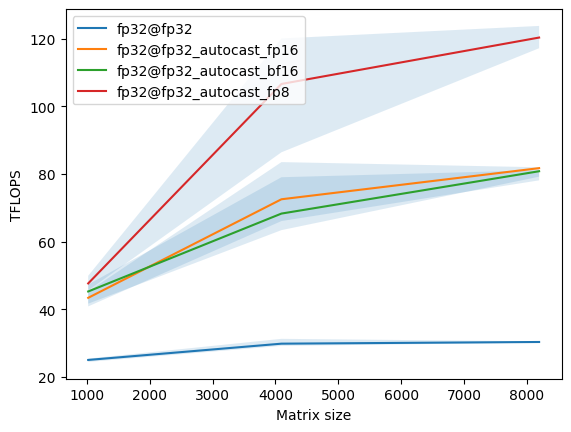

In [ ]:
test_shapes = [
    [1024, 1024, 1024],
    [4096, 4096, 4096],
    [8192, 8192, 8192],
    # [2**14, 2**14, 2**14]
    ]

experiments = [
            "fp32@fp32",
            # "fp16@fp32",
            # "fp16@fp16",
            # "bf16@bf16",
            # "fp32@fp32_set_float32_matmul_precision",
            "fp32@fp32_autocast_fp16",
            "fp32@fp32_autocast_bf16",
            "fp32@fp32_autocast_fp8",
            # "fp8@fp8",
            # "int8@int8",
            ]

configs = []
configs.append(
    triton.testing.Benchmark(
        x_names=["K", "M", "N"],
        x_vals=[shape for shape in test_shapes],
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        line_vals=experiments,
        line_names=experiments,
        ylabel="TFLOPS",  # Label name for the y-axis
        xlabel="Matrix size",
        plot_name="matmul-performance",  # Name for the plot, used also as a file name for saving the plot.
        args={},
    ))

@triton.testing.perf_report(configs)
def benchmark(M, K, N, provider):

    if provider == "fp32@fp32":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp32_fp32,
            matmul_fn=torch.matmul
        )
    if provider == "fp16@fp16":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp16_fp16,
            matmul_fn=torch.matmul
        )
    # if provider == "fp16@fp32":
    #     perf = benchmark_matmul(
    #         M=M, N=N, K=K,
    #         prepare_args_fn=prepare_args_fp16_fp32,
    #         matmul_fn=torch.matmul
    #     )
    if provider == "bf16@bf16":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_bf16_bf16,
            matmul_fn=torch.matmul
        )
    if provider == "fp32@fp32_set_float32_matmul_precision":
        torch.set_float32_matmul_precision("high")
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp32_fp32,
            matmul_fn=torch.matmul
        )
        torch.set_float32_matmul_precision("highest")
    if provider == "fp32@fp32_autocast_fp16":
        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            perf = benchmark_matmul(
                M=M, N=N, K=K,
                prepare_args_fn=prepare_args_fp32_fp32,
                matmul_fn=torch.matmul
            )
    if provider == "fp32@fp32_autocast_bf16":
        with torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16):
            perf = benchmark_matmul(
                M=M, N=N, K=K,
                prepare_args_fn=prepare_args_fp32_fp32,
                matmul_fn=torch.matmul
            )
    if provider == "fp32@fp32_autocast_fp8":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp32_fp32,
            matmul_fn=matmul_autocast_fp8
        )
    if provider == "int8@int8":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_int8_int8,
            matmul_fn=matmul_int8_int8
        )
    if provider == "fp8@fp8":
        perf = benchmark_matmul(
            M=M, N=N, K=K,
            prepare_args_fn=prepare_args_fp8_fp8,
            matmul_fn=matmul_fp8_fp8
        )
    return perf

bench_data = benchmark.run(show_plots=False, print_data=True, return_df=True)[0]